In [25]:
from learning.models import PointNetPlusPlus, PointNetPlusPlusUnmasked
from learning.datatools import ApplePointCloudDataset, AppleInstancePointCloudDataset
import torch
from torch.utils.data import DataLoader
import plotly.graph_objects as go
import os 
import time
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [26]:
RUN_DIR = '/home/keyi/sid/learning2localize/logs/fixed_dataset_full_noise/20250618-152521-98f79773'

In [27]:
import json 

pth = f'{RUN_DIR}/config.json'
with open(pth, 'r') as f:
    config = json.load(f)
# config['mask_augment'] = False


In [28]:
SEED = 77
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [29]:
ds = AppleInstancePointCloudDataset(
    data_root="blender/dataset/raw/sample_rate16_processed",
    manifest_path= "blender/dataset/curated/sample_rate16_processed/test.jsonl",
    config=config,
    augment=True,
)
dl = DataLoader(ds, batch_size=1, shuffle=True, num_workers=0)
model =PointNetPlusPlusUnmasked(input_dim=3, output_dim=2, 
                        npoints=[512, 128, 32],
                        radii=[0.01, 0.05, 0.15],
                        nsamples=[32, 64, 128],
                        mlp_channels=[
                            [64, 64, 128],
                            [128, 128, 256], 
                            [256, 256, 512]  
                        ]).cuda()

ckpt_path = f'{RUN_DIR}/best_model.pth'
model.load_state_dict(torch.load(ckpt_path, map_location='cuda'))
model.eval()

Loading 3899 scenes from blender/dataset/curated/sample_rate16_processed/test.jsonl …


/tmp/ipykernel_2474082/849609453.py:19: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



PointNetPlusPlusUnmasked(
  (sa1): PointNetSetAbstractionUnmasked(
    (mlp_convs): ModuleList(
      (0): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (2): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (sa2): PointNetSetAbstractionUnmasked(
    (mlp_convs): ModuleList(
      (0): Conv2d(131, 128, kernel_size=(1, 1), stride=(1, 1))
      (1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
      (2): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (sa3): PointNetSetAbstractionUnmasked(
    (mlp_convs): ModuleList(
      (0): Conv2d(259, 256, kernel_size=(1, 1), stride=(1, 1))
      (1): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
      (2): Conv2d(256, 512, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=1024, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=512, bias=True)
    (3): R

In [30]:
from  sklearn.neighbors import LocalOutlierFactor
def lof(points):
    '''
    Calculate the density of points using Local Outlier Factor (LOF). final metric is given by # of outliers / number of inliers
    points: (N, 3) numpy array of point coordinates
    returns: density score, higher is more dense
    0.0 is no outliers, 1.0 is all outliers
    '''
    lof = LocalOutlierFactor(n_neighbors=20)
    preds = lof.fit_predict(points)
    n_outliers = np.sum(preds == -1)
    n_inliers = np.sum(preds == 1)
    if n_inliers == 0:
        return 1.0
    return n_outliers / (n_inliers + n_outliers)
def curvature(points):
    '''
    Calculate the curvature of points using the Laplacian operator.
    points: (N, 3) numpy array of point coordinates
    returns: curvature score, higher is more curved
    '''
    if len(points) < 3:
        return 0.0
    points = points - np.mean(points, axis=0)
    cov = np.cov(points.T)
    eigenvalues, _ = np.linalg.eig(cov)
    return np.sum(eigenvalues) / len(eigenvalues)

In [31]:
mean_z_err = 0.0
error_thresh = 0.03  
error_cases = []
feats_errs = []
times = []
for i, (clouds, centers, aux) in enumerate(dl):
    clouds = clouds.cuda()
    clouds_input = clouds[:, :, :model.input_dim+3]  # Keep only the first 6 channels (x, y, z, r, g, b)
    centers = centers.cuda()
    # masks = masks.cuda()
    occ_rate = aux['occ_rate'].unsqueeze(1).float().cuda()
    norm_scale = aux["norm_scale"].view(-1, 1).cuda()
    norm_center = aux["norm_center"].cuda()
    # concat centers and occ_batch to a labels tensor of shape (B, 4)
    labels = centers[:,2].unsqueeze(1).float()
    labels = torch.cat([labels, occ_rate], dim=1)
    with torch.no_grad():
        torch.cuda.synchronize()
        t0 = time.time()
        global_feats, outputs = model(clouds_input)
        torch.cuda.synchronize()
        times.append(time.time() - t0)

    pred_z = outputs[:, 0].unsqueeze(1)
    label_z = labels[:, 0].unsqueeze(1)
    z_errs_m = (pred_z - label_z).abs() * norm_scale

    z_err_m = z_errs_m[0]
    # print(f"Cloud {i} Z Error Mean (mm): {z_err_m.mean().item() * 1000:.4f} mm")
    # if z_err_m > 0.05:

    clouds = clouds.squeeze(0)
    centers = centers.squeeze(0)
    pred_z = pred_z.squeeze(0)
    z_errs_m = z_errs_m.squeeze(0)
    norm_scale = norm_scale.squeeze(0)
    norm_center = norm_center.squeeze(0)

    pc_m = (clouds[ :, :3].detach()* norm_scale + norm_center).cpu().numpy()
    gt_center_m = (centers[ :3] * norm_scale + norm_center).cpu().numpy()

    pred_center_m = (torch.tensor([centers[0].item(), centers[1].item(), pred_z[0].item()]).cuda() 
                        * norm_scale + norm_center).cpu().numpy()
    
    mean_z_err += z_errs_m.mean().item()

    density_score = lof(pc_m)
    curvature_score = curvature(pc_m)


    feats_errs.append({
        'global_feats': global_feats.detach().cpu().numpy(),
        'gt_center_m': gt_center_m.tolist(),
        'pred_center_m': pred_center_m.tolist(),
        'z_err_m': z_err_m * 1000,  # convert to mm
        'density_score': density_score,
        'curvature_score': curvature_score,
        'gt_occ_rate': occ_rate.item(),
        'pred_occ_rate': outputs[0, 1].item(),
        'num_points': clouds.shape[0],
    })

    print(f"Cloud {i} Running mean Z error: {mean_z_err / (i + 1) * 1000:.4f} mm")
    if z_err_m <0.025:
        continue

    # append sample to error cases
    error_cases.append({
        "cloud_index": i,
        "pred_center": pred_center_m.tolist(),
        "gt_center": gt_center_m.tolist(),
        "z_error": z_err_m.mean().item() * 1000,  # convert to mm
        "norm_scale": norm_scale.cpu().numpy().tolist(),
        "norm_center": norm_center.cpu().numpy().tolist(),
        "cloud": clouds.cpu().numpy().tolist(),
        "labels": labels.cpu().numpy().tolist(),
        "outputs": outputs.detach().cpu().numpy().tolist(),
        "aux": aux,
        "aux_stem": aux["stem"][0],
        "aux_bbox": aux["bbox"]
    })
    

mean_z_err /= len(dl)

Cloud 0 Running mean Z error: 1.1036 mm
Cloud 1 Running mean Z error: 1.2200 mm
Cloud 2 Running mean Z error: 2.1076 mm
Cloud 3 Running mean Z error: 4.8765 mm
Cloud 4 Running mean Z error: 4.2855 mm
Cloud 5 Running mean Z error: 4.2968 mm
Cloud 6 Running mean Z error: 6.0894 mm
Cloud 7 Running mean Z error: 5.4320 mm
Cloud 8 Running mean Z error: 4.8650 mm
Cloud 9 Running mean Z error: 4.6238 mm
Cloud 10 Running mean Z error: 4.6188 mm
Cloud 11 Running mean Z error: 4.3833 mm
Cloud 12 Running mean Z error: 4.5671 mm
Cloud 13 Running mean Z error: 4.3906 mm
Cloud 14 Running mean Z error: 4.1277 mm
Cloud 15 Running mean Z error: 4.3159 mm
Cloud 16 Running mean Z error: 4.3145 mm
Cloud 17 Running mean Z error: 4.0790 mm
Cloud 18 Running mean Z error: 3.9733 mm
Cloud 19 Running mean Z error: 4.8654 mm
Cloud 20 Running mean Z error: 5.4594 mm
Cloud 21 Running mean Z error: 5.4722 mm
Cloud 22 Running mean Z error: 6.1151 mm
Cloud 23 Running mean Z error: 6.0042 mm
Cloud 24 Running mean Z er

FileNotFoundError: Data for aa0000ef-8d09-40d5-8c76-f8ce57f6bece not found in blender/dataset/raw/sample_rate16_processed. Please check the paths.

/home/keyi/sid/learning2localize/venv/lib/python3.8/site-packages/plotly/io/_renderers.py:55: UserWarning:

Plotly version >= 6 requires Jupyter Notebook >= 7 but you have 6.5.7 installed.
 To upgrade Jupyter Notebook, please run `pip install notebook --upgrade`.



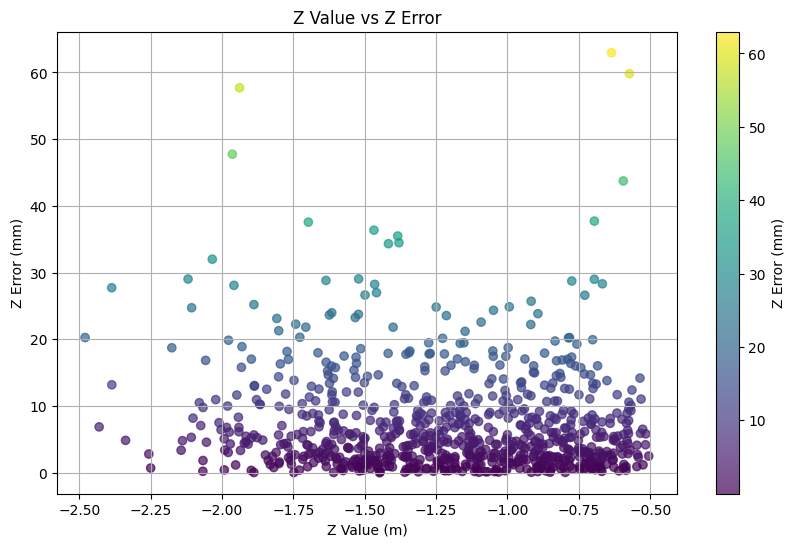

Pearson correlation coefficient (r) between predicted and ground truth occupancy rates: 0.9601


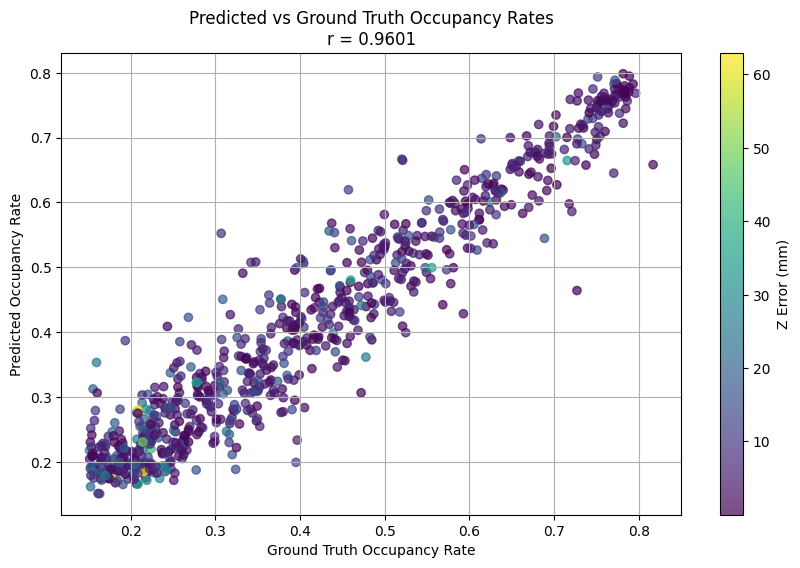

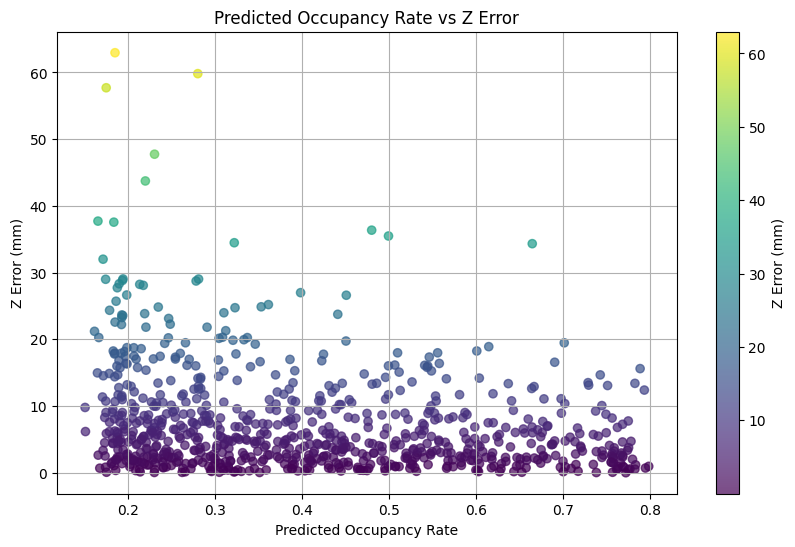

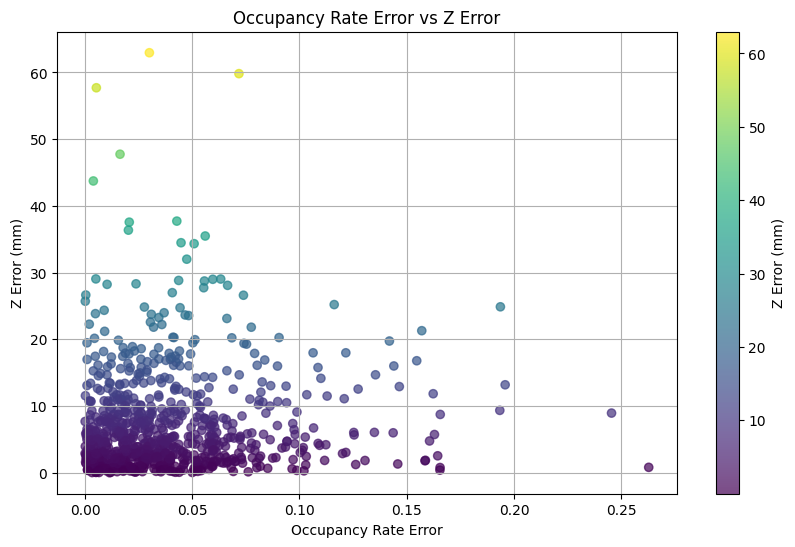

In [32]:
centers_m = np.array([feat['gt_center_m'] for feat in feats_errs])
centers_xys = centers_m[:, :2]
errs_m = np.array([feat['z_err_m'].cpu().numpy() for feat in feats_errs])
# Create interactive 3D scatter plot using plotly
fig = go.Figure(data=[go.Scatter3d(
    x=centers_xys[:, 0],
    y=centers_xys[:, 1], 
    z=errs_m.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color=errs_m.flatten(),
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Z Error (mm)")
    ),
    text=[f'X: {x:.3f}m<br>Y: {y:.3f}m<br>Error: {z:.1f}mm' 
          for x, y, z in zip(centers_xys[:, 0], centers_xys[:, 1], errs_m.flatten())],
    hovertemplate='%{text}<extra></extra>'
)])

fig.update_layout(
    title='Interactive 3D Scatter Plot of Centers XY vs Z Error',
    scene=dict(
        xaxis_title='X (m)',
        yaxis_title='Y (m)',
        zaxis_title='Z Error (mm)'
    ),
    width=800,
    height=600
)

fig.show()

# matplotlib plot z value vs error
plt.figure(figsize=(10, 6))
plt.scatter(centers_m[:, 2], errs_m, c=errs_m, cmap='viridis', alpha=0.7)
plt.colorbar(label='Z Error (mm)')
plt.xlabel('Z Value (m)')
plt.ylabel('Z Error (mm)')
plt.title('Z Value vs Z Error')
plt.grid()
plt.show()

pred_occ_rates = np.array([feat['pred_occ_rate'] for feat in feats_errs])
gt_occ_rates = np.array([feat['gt_occ_rate'] for feat in feats_errs])
# get r value
from scipy.stats import pearsonr
r_value, _ = pearsonr(pred_occ_rates, gt_occ_rates)
print(f"Pearson correlation coefficient (r) between predicted and ground truth occupancy rates: {r_value:.4f}")
plt.figure(figsize=(10, 6))
plt.scatter(gt_occ_rates, pred_occ_rates, c=errs_m, cmap='viridis', alpha=0.7)
plt.colorbar(label='Z Error (mm)')
plt.xlabel('Ground Truth Occupancy Rate')
plt.ylabel('Predicted Occupancy Rate')
plt.title(f'Predicted vs Ground Truth Occupancy Rates\nr = {r_value:.4f}')
plt.grid()
plt.show()

# pred occ rate vs error
plt.figure(figsize=(10, 6))
plt.scatter(pred_occ_rates, errs_m, c=errs_m, cmap='viridis', alpha=0.7)
plt.colorbar(label='Z Error (mm)')
plt.xlabel('Predicted Occupancy Rate')
plt.ylabel('Z Error (mm)')
plt.title('Predicted Occupancy Rate vs Z Error')
plt.grid()
plt.show()

occ_rate_errs = np.abs(pred_occ_rates - gt_occ_rates)
plt.figure(figsize=(10, 6))
plt.scatter(occ_rate_errs, errs_m, c=errs_m, cmap='viridis', alpha=0.7)
plt.colorbar(label='Z Error (mm)')
plt.xlabel('Occupancy Rate Error')
plt.ylabel('Z Error (mm)')
plt.title('Occupancy Rate Error vs Z Error')
plt.grid()
plt.show()

In [33]:
mean_z_err

5.853980156096647

In [34]:
len(error_cases), len(dl), len(error_cases)/len(dl)

(26, 5660, 0.004593639575971731)

In [35]:
np.random.shuffle(error_cases)
# sort high to low by z_error
error_cases = sorted(error_cases, key=lambda x: x['z_error'], reverse=True)

Error Case 0 Z Error Mean (mm): 62957.9855 mm
Predicted Center: [-0.026391991989188644, -0.15505778808809342, -0.698300643189497]
GT Center: [-0.026391991989188644, -0.15505778808809342, -0.6353426603994554]
Cloud 0  BBox: tensor([492,  73, 641,   0]) Cloud Shape: (2422, 6)


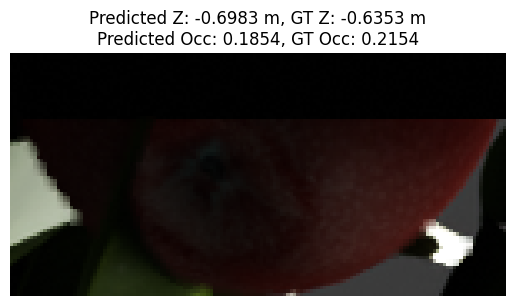

Error Case 1 Z Error Mean (mm): 59822.1565 mm
Predicted Center: [-0.021513948833201728, -0.12634295230167705, -0.6325805926662905]
GT Center: [-0.021513948833201728, -0.12634295230167705, -0.5727584361457778]
Cloud 1  BBox: tensor([493, 119, 653,   0]) Cloud Shape: (4025, 6)


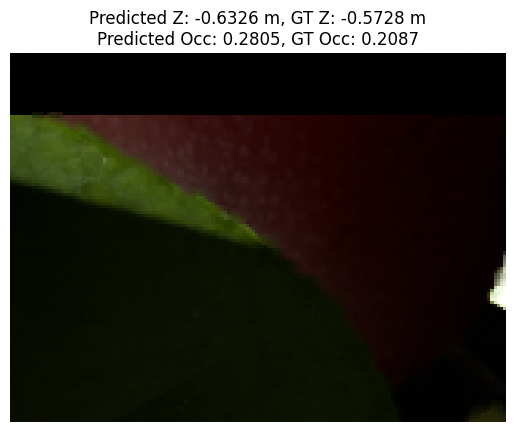

Error Case 2 Z Error Mean (mm): 57705.3778 mm
Predicted Center: [-0.06271842167188053, 0.10531822600352503, -1.8806439876207839]
GT Center: [-0.06271842167188053, 0.10531822600352503, -1.9383493669406755]
Cloud 2  BBox: tensor([553, 475, 612, 408]) Cloud Shape: (259, 6)


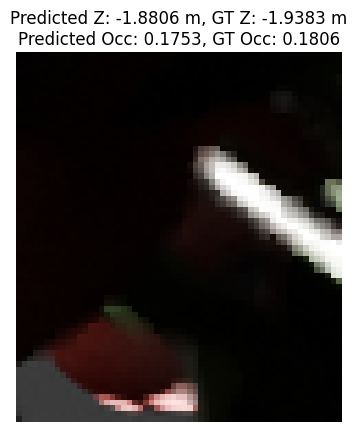

Error Case 3 Z Error Mean (mm): 47747.1370 mm
Predicted Center: [-0.05418876232896412, -0.12156565494010647, -1.9159516075256862]
GT Center: [-0.05418876232896412, -0.12156565494010647, -1.9636987445688563]
Cloud 3  BBox: tensor([548, 307, 634, 227]) Cloud Shape: (787, 6)


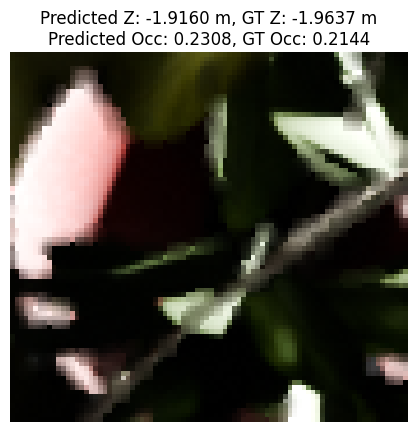

Error Case 4 Z Error Mean (mm): 43736.7487 mm
Predicted Center: [-0.02058309513792369, -0.14546258766455958, -0.6380115657904079]
GT Center: [-0.02058309513792369, -0.14546258766455958, -0.5942748170922223]
Cloud 4  BBox: tensor([500,  79, 657,   0]) Cloud Shape: (3208, 6)


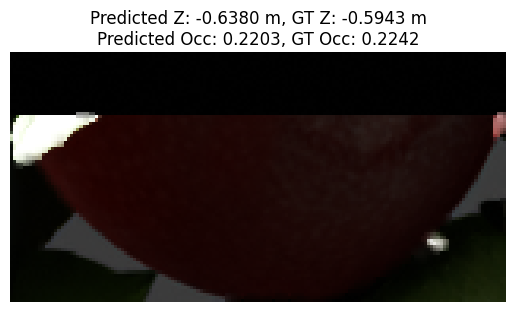

Error Case 5 Z Error Mean (mm): 37719.5286 mm
Predicted Center: [-0.03802165773420085, -0.14409086116530487, -0.7333451340888439]
GT Center: [-0.03802165773420085, -0.14409086116530487, -0.6956256054795393]
Cloud 5  BBox: tensor([464, 114, 621,   0]) Cloud Shape: (1131, 6)


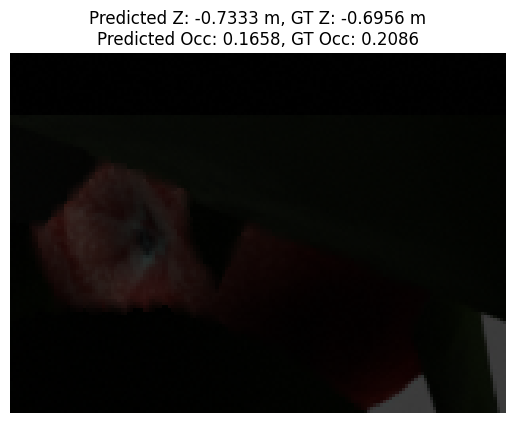

Error Case 6 Z Error Mean (mm): 37563.3570 mm
Predicted Center: [-0.11967810982225144, -0.0819754530080079, -1.6599471232327685]
GT Center: [-0.11967810982225144, -0.0819754530080079, -1.69751048019656]
Cloud 6  BBox: tensor([466, 331, 564, 245]) Cloud Shape: (973, 6)


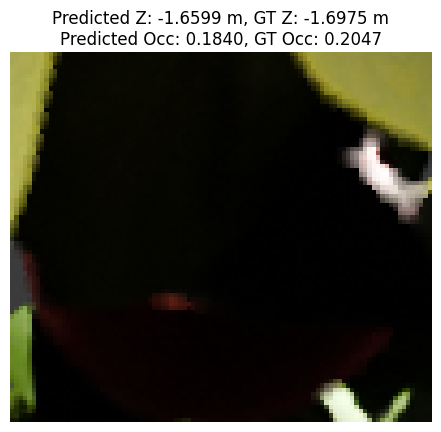

Error Case 7 Z Error Mean (mm): 36362.9740 mm
Predicted Center: [-0.12944100799131464, -0.12814769101335474, -1.4312320060147148]
GT Center: [-0.12944100799131464, -0.12814769101335474, -1.4675949815993243]
Cloud 7  BBox: tensor([432, 286, 535, 172]) Cloud Shape: (4080, 6)


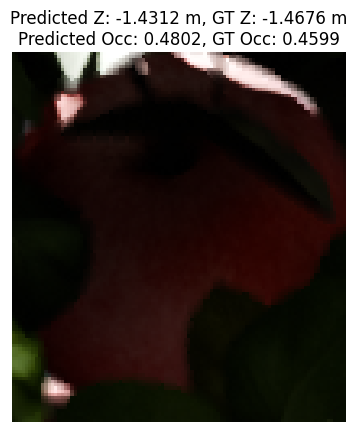

Error Case 8 Z Error Mean (mm): 35486.9916 mm
Predicted Center: [0.4513158202769465, -0.13351717551669143, -1.3488672405146207]
GT Center: [0.4513158202769465, -0.13351717551669143, -1.384354233997412]
Cloud 8  BBox: tensor([1162,  266, 1277,  165]) Cloud Shape: (3619, 6)


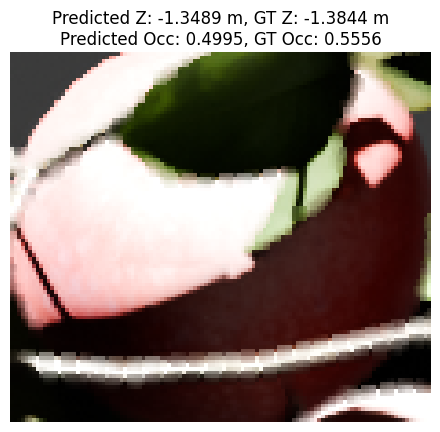

Error Case 9 Z Error Mean (mm): 34478.1730 mm
Predicted Center: [-0.4330303680415621, -0.2823669613159538, -1.3456026458341204]
GT Center: [-0.4330303680415621, -0.2823669613159538, -1.3800808188230644]
Cloud 9  BBox: tensor([ 20, 110, 144,   0]) Cloud Shape: (2187, 6)


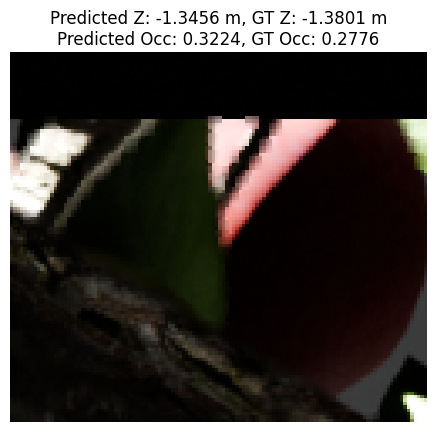

Error Case 10 Z Error Mean (mm): 34335.4888 mm
Predicted Center: [0.02480952792217424, -0.17178857333313335, -1.382582550664736]
GT Center: [0.02480952792217424, -0.17178857333313335, -1.4169180394980412]
Cloud 10  BBox: tensor([623, 228, 719, 128]) Cloud Shape: (4752, 6)


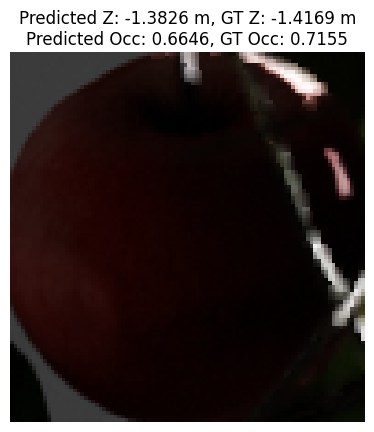

Error Case 11 Z Error Mean (mm): 32010.9796 mm
Predicted Center: [0.1056087909672274, -0.17945593612674327, -2.0019181301609543]
GT Center: [0.1056087909672274, -0.17945593612674327, -2.033929109716117]
Cloud 11  BBox: tensor([708, 255, 757, 200]) Cloud Shape: (175, 6)


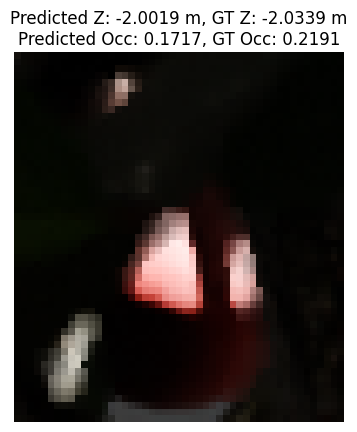

In [36]:
for i in range(len(error_cases)):
    aux = error_cases[i]["aux"]
    clouds = np.array(error_cases[i]["cloud"])
    labels = np.array(error_cases[i]["labels"])
    outputs = np.array(error_cases[i]["outputs"])
    pred_center_m = error_cases[i]["pred_center"]
    gt_center_m = error_cases[i]["gt_center"]
    norm_scale = error_cases[i]["norm_scale"]
    norm_center = error_cases[i]["norm_center"]
    pc_m = (clouds[:, :3] * norm_scale + norm_center)
    z_err_m = error_cases[i]["z_error"]
    print(f"Error Case {i} Z Error Mean (mm): {z_err_m * 1000:.4f} mm")
    print(f"Predicted Center: {pred_center_m}")
    print(f"GT Center: {gt_center_m}")
    stem = aux["stem"][0]
    rgb_path = os.path.join(ds.root, stem + '_rgb0107.png')
    assert os.path.exists(rgb_path), f"RGB path {rgb_path} does not exist"
    rgb = cv2.cvtColor(cv2.imread(rgb_path), cv2.COLOR_BGR2RGB)
    bbox = aux["bbox"].squeeze(0)
    print(f"Cloud {i}  BBox: {bbox} Cloud Shape: {clouds.shape}")
    # continue
    x1, y1, x2, y2 = bbox
    x1, x2 = min(x1, x2), max(x1, x2)
    y1, y2 = min(y1, y2), max(y1, y2)
    rgb = rgb[y1:y2, x1:x2, :]
    plt.imshow(rgb)
    plt.axis('off')
    plt.title(f"Predicted Z: {pred_center_m[2]:.4f} m, GT Z: {gt_center_m[2]:.4f} m\nPredicted Occ: {outputs[0,1]:.4f}, GT Occ: {labels[0,1]:.4f}")
    plt.show()
    
    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=pc_m[:, 0],
        y=pc_m[:, 1],
        z=pc_m[:, 2],
        mode='markers',
        marker=dict(size=2, color=clouds[ :, 3:], opacity=0.8),
    ))
    fig.add_trace(go.Scatter3d(
        x=[gt_center_m[0]],
        y=[gt_center_m[1]],
        z=[gt_center_m[2]],
        mode='markers',
        marker=dict(size=5, color='red'),
        name='GT Center',
    ))
    fig.add_trace(go.Scatter3d(
        x=[pred_center_m[0]],
        y=[pred_center_m[1]],
        z=[pred_center_m[2]],
        mode='markers',
        marker=dict(size=5, color='blue'),
        name='Pred Center',
    ))
    fig.update_layout(title=f"Cloud {i} Z Error: {np.mean(z_err_m):.4f}")
    fig.show()
    if i >10 : break
   

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 795 samples in 0.000s...
[t-SNE] Computed neighbors for 795 samples in 0.303s...
[t-SNE] Computed conditional probabilities for sample 795 / 795
[t-SNE] Mean sigma: 0.089623
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.679688
[t-SNE] KL divergence after 1000 iterations: 1.202513


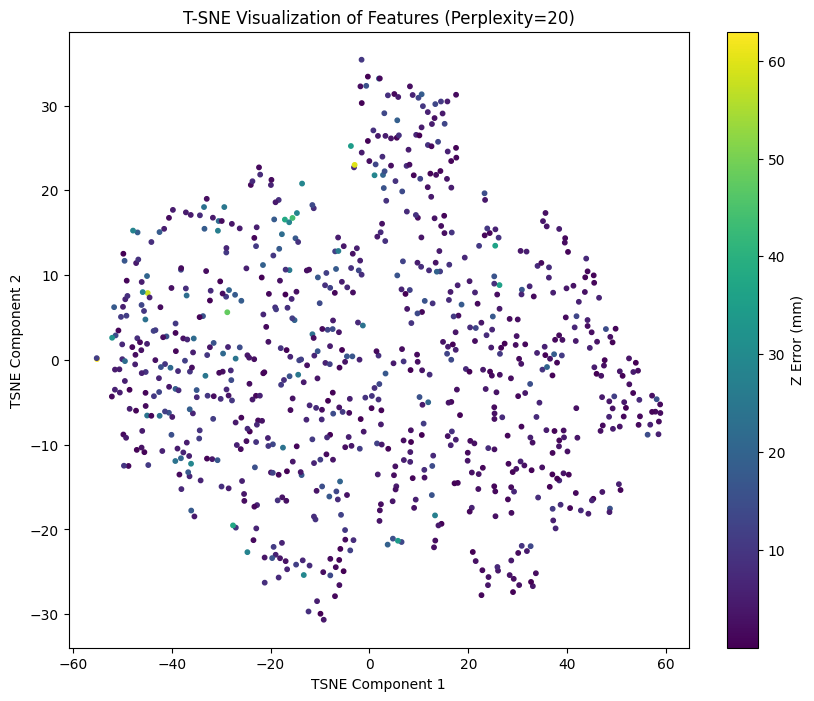

In [37]:
#tsne on feats
from sklearn.manifold import TSNE
SEED = 9
np.random.seed(SEED)
import random
random.seed(SEED)
feats = np.array([feat['global_feats'] for feat in feats_errs])
errs = np.array([feat['z_err_m'].item() for feat in feats_errs])
perplexity = 20
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=SEED, n_iter=1000, verbose=1)
feats_2d = tsne.fit_transform(np.concatenate(feats, axis=0))

plt.figure(figsize=(10, 8))
scatter = plt.scatter(feats_2d[:, 0], feats_2d[:, 1], c=errs, cmap='viridis', s=10)
plt.colorbar(scatter, label='Z Error (mm)')
plt.title(f'T-SNE Visualization of Features (Perplexity={perplexity})')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.show()

In [38]:
for i, (clouds, centers, aux) in enumerate(dl):
    
    clouds = clouds.cuda()
    clouds = clouds[:, :, :6]  # Keep only the first 6 channels (x, y, z, r, g, b)
    centers = centers.cuda()
    # masks = masks.cuda()
    occ_rate = aux['occ_rate'].unsqueeze(1).float().cuda()
    norm_scale = aux["norm_scale"].view(-1, 1).cuda()
    norm_center = aux["norm_center"].cuda()
    # concat centers and occ_batch to a labels tensor of shape (B, 4)
    labels = centers[:,2].unsqueeze(1).float()
    labels = torch.cat([labels, occ_rate], dim=1)
    with torch.no_grad():
        outputs = model(clouds)

    pred_z = outputs[:, 0].unsqueeze(1)
    label_z = labels[:, 0].unsqueeze(1)
    z_errs_m = (pred_z - label_z).abs() * norm_scale

    z_err_m = z_errs_m[0]
    # print(f"Cloud {i} Z Error Mean (mm): {z_err_m.mean().item() * 1000:.4f} mm")
    # if z_err_m > 0.05:

    clouds = clouds.squeeze(0).detach()
    centers = centers.squeeze(0)
    pred_z = pred_z.squeeze(0)
    z_errs_m = z_errs_m.squeeze(0)
    norm_scale = norm_scale.squeeze(0)
    norm_center = norm_center.squeeze(0)

    pc_m = (clouds[ :, :3]* norm_scale + norm_center).cpu().numpy()
    gt_center_m = (centers[ :3] * norm_scale + norm_center).cpu().numpy()

    pred_center_m = (torch.tensor([centers[0].item(), centers[1].item(), pred_z[0].item()]).cuda() 
                        * norm_scale + norm_center).cpu().numpy()
    

    stem = aux["stem"][0]
    rgb_path = os.path.join(ds.root, stem + '_rgb0000.png')
    assert os.path.exists(rgb_path), f"RGB path {rgb_path} does not exist"
    rgb = cv2.cvtColor(cv2.imread(rgb_path), cv2.COLOR_BGR2RGB)
    bbox = aux["bbox"].squeeze(0)
    print(f"Cloud {i}  BBox: {bbox}")
    x1, y1, x2, y2 = bbox
    x1, x2 = min(x1, x2), max(x1, x2)
    y1, y2 = min(y1, y2), max(y1, y2)
    rgb = rgb[y1:y2, x1:x2, :]
    plt.imshow(rgb)
    plt.axis('off')
    plt.title(f"Predicted Z: {pred_center_m[2]:.4f} m, GT Z: {gt_center_m[2]:.4f} m\nPredicted Occ: {outputs[0,1]:.4f}, GT Occ: {labels[0,1]:.4f}")
    plt.show()
    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=pc_m[:, 0],
        y=pc_m[:, 1],
        z=pc_m[:, 2],
        mode='markers',
        marker=dict(size=2, color=clouds[ :, 3:].cpu().numpy(), opacity=0.8),
    ))
    fig.add_trace(go.Scatter3d(
        x=[gt_center_m[0]],
        y=[gt_center_m[1]],
        z=[gt_center_m[2]],
        mode='markers',
        marker=dict(size=5, color='red'),
        name='GT Center',
    ))
    fig.add_trace(go.Scatter3d(
        x=[pred_center_m[0]],
        y=[pred_center_m[1]],
        z=[pred_center_m[2]],
        mode='markers',
        marker=dict(size=5, color='blue'),
        name='Pred Center',
    ))
    fig.update_layout(title=f"Cloud {i} Z Error:"+ str(1000*z_err_m.item()) + 'mm')
    fig.show()
    if i >10 : break

RuntimeError: Given groups=1, weight of size [64, 3, 1, 1], expected input[1, 6, 32, 512] to have 3 channels, but got 6 channels instead

In [39]:
from sklearn.cluster import DBSCAN

def dbscan_localize(pc_3d, eps=10, min_samples=20):
    """
    Perform DBSCAN clustering on the 3D point cloud to find the center of the largest cluster.
    :param pc_3d: (N, 3) numpy array of 3D points
    :param eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
    :param min_samples: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
    :return: The median z value of the largest cluster center in the point cloud.
    """
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(pc_3d)
    labels = db.labels_
    
    if len(set(labels)) <= 1:
        return None  # No clusters found or only noise
    
    unique_labels = set(labels)
    largest_cluster_label = max(unique_labels, key=lambda x: np.sum(labels == x))
    largest_cluster_points = pc_3d[labels == largest_cluster_label]

    return np.median(largest_cluster_points, axis=0)[2]  # Return only Z coordinate

In [ ]:
dataset_size = len(ds)
subset_size = 0.05
subset_indices = np.random.choice(dataset_size, int(dataset_size * subset_size), replace=False)
subset_ds = torch.utils.data.Subset(ds, subset_indices)
subset_dl = DataLoader(subset_ds, batch_size=1, shuffle=True, num_workers=0)
print("Searching using subset len", len(subset_ds))

# search for best eps and min_samples on subset data
eps_values = [2, 5, 10, 15, 20]
min_samples_values =[5, 10, 20, 30, 50, 60]
best_eps = None
best_min_samples = None
best_avg_err = float('inf')

for eps in eps_values:
    for min_samples in min_samples_values:
        err = 0
        for i, (clouds, centers, aux) in enumerate(dl):
            all_points = []
            cloud = clouds.squeeze(0)
            norm_scale = aux["norm_scale"].view(-1, 1).squeeze(0)
            norm_center = aux["norm_center"].squeeze(0)

            
            pc_3d = (cloud[ :, :3].detach().clone() * norm_scale + norm_center).cpu().numpy()
            pred_z = dbscan_localize(pc_3d, eps=eps/1000, min_samples=min_samples)
            if pred_z is None:
                pred_z = label_z//2

            centers = (centers.cpu()*norm_scale.cpu()) + norm_center.cpu()
            label_z = centers[:,2]
            err+= abs(pred_z - label_z.item())
            print("err", abs(pred_z - label_z.item()), "pred_z", pred_z, "label_z", label_z.item())
        avg_err = err / len(dl)
        if avg_err < best_avg_err:
            best_eps = eps
            best_min_samples = min_samples
            best_avg_err = avg_err
print(f"Best eps: {best_eps:.2f}, Best min_samples: {best_min_samples}, Best avg_err: {best_avg_err:.4f}")

In [41]:
z_errs = []
dbscan_errs = []
occ_rates = []
just_mean_errs = []
dl = DataLoader(ds, batch_size=1, shuffle=True, num_workers=0, )
model.eval()


for i, (clouds, centers, aux) in enumerate(dl):
    clouds = clouds.cuda()
    clouds = clouds[:, :, :3]  # Keep only the first 6 channels (x, y, z, r, g, b)
    centers = centers.cuda()
    # masks = masks.cuda()
    occ_rate = aux['occ_rate'].unsqueeze(1).float().cuda()
    norm_scale = aux["norm_scale"].view(-1, 1).cuda()
    norm_center = aux["norm_center"].cuda()
    # concat centers and occ_batch to a labels tensor of shape (B, 4)
    labels = centers[:,2].unsqueeze(1).float()
    labels = torch.cat([labels, occ_rate], dim=1)
    _, outputs = model(clouds)

    pred_z = outputs[:, 0].unsqueeze(1)
    label_z = labels[:, 0].unsqueeze(1)
    z_errs_m = (pred_z - label_z).abs() * norm_scale


    naiive_mean_z = clouds[:,2].mean(dim=1)
    naiive_mean_z_err = (label_z - naiive_mean_z).abs()

    naiive_mean_z_err_m = naiive_mean_z_err.abs() * norm_scale

    pc_3d = (clouds[0, :, :3].detach().clone() * norm_scale + norm_center).cpu().numpy()
    dbscan_z = dbscan_localize(pc_3d, eps=0.05, min_samples=20)
    if dbscan_z is not None:
        dbscan_z_err = abs(dbscan_z - (label_z*norm_scale + norm_center)[0, 2].item())
    else:
        dbscan_z_err = float('nan')
    # print(f"Deep learning Z Error Mean (mm): {z_errs_m.mean() * 1000:.4f} mm; \
    #       Naiive Mean Z Error Mean (mm): {naiive_mean_z_err_m.mean() * 1000:.4f} mm; \
    #       DBSCAN Z Error Mean (mm): {dbscan_z_err * 1000:.4f} mm")

    z_errs.extend(z_errs_m.detach().cpu().numpy().flatten().tolist())
    just_mean_errs.extend(naiive_mean_z_err_m.detach().cpu().numpy().flatten().tolist())
    dbscan_errs.append(dbscan_z_err)
    occ_rates.extend(occ_rate.cpu().numpy().flatten().tolist())


KeyboardInterrupt: 

In [ ]:
len(z_errs)

Mean Z Error across all batches: 0.0071


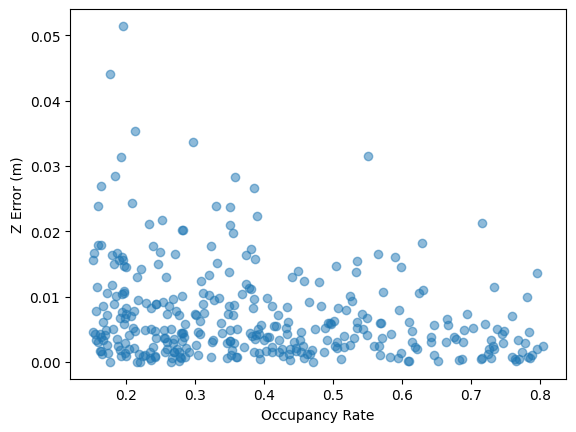

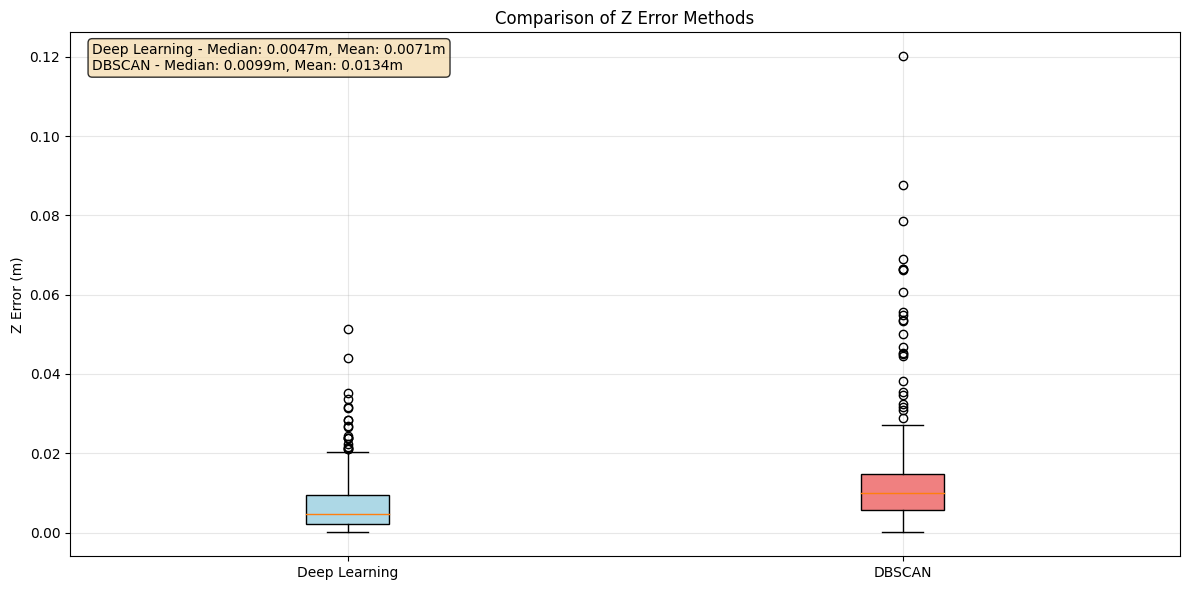

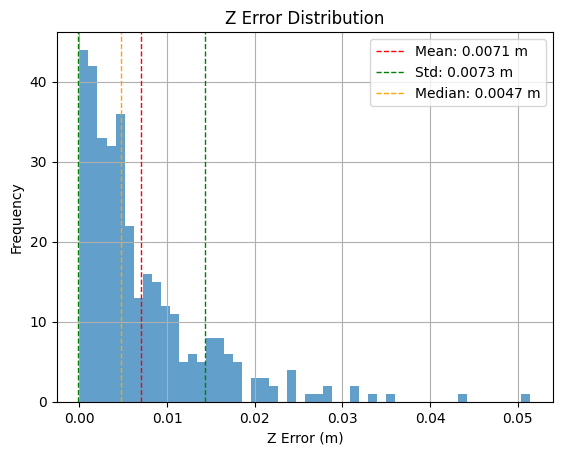

Percentage of Z Errors above 0.03 m: 1.76%


In [43]:
print(f"Mean Z Error across all batches: {np.mean(z_errs):.4f}")
    
plt.scatter(occ_rates, z_errs, alpha=0.5)
plt.xlabel('Occupancy Rate')
plt.ylabel('Z Error (m)')
plt.show()


# Create comparison boxplots side by side
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Create data for both methods
dbscan_errs_clean = [err for err in dbscan_errs if not np.isnan(err)]

# Create boxplots side by side
bp = ax.boxplot([z_errs, dbscan_errs_clean], 
                labels=['Deep Learning', 'DBSCAN'],
                patch_artist=True)

# Color the boxes differently
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

ax.set_ylabel('Z Error (m)')
ax.set_title('Comparison of Z Error Methods')
ax.grid(True, alpha=0.3)

# Add statistics as text
dl_median = np.median(z_errs)
dl_mean = np.mean(z_errs)
dbscan_median = np.median(dbscan_errs_clean)
dbscan_mean = np.mean(dbscan_errs_clean)

stats_text = f'Deep Learning - Median: {dl_median:.4f}m, Mean: {dl_mean:.4f}m\n'
stats_text += f'DBSCAN - Median: {dbscan_median:.4f}m, Mean: {dbscan_mean:.4f}m'

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()



# distribution
plt.hist(z_errs, bins=50, alpha=0.7)
mean = np.mean(z_errs)
std = np.std(z_errs)
plt.axvline(mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean:.4f} m')
plt.axvline(mean + std, color='green', linestyle='dashed', linewidth=1, label=f'Std: {std:.4f} m')
plt.axvline(mean - std, color='green', linestyle='dashed', linewidth=1)
median = np.median(z_errs)
plt.axvline(median, color='orange', linestyle='dashed', linewidth=1, label=f'Median: {median:.4f} m')   
plt.legend()
plt.grid()
plt.xlabel('Z Error (m)')
plt.ylabel('Frequency')
plt.title('Z Error Distribution')
plt.show()





threshold = 0.03
num_above_threshold = sum(1 for err in z_errs if err > threshold)
print(f"Percentage of Z Errors above {threshold} m: {num_above_threshold / len(z_errs) * 100:.2f}%")

In [ ]:
from learning.datatools import RealAppleInstancePointCloudDataset

In [ ]:
ds = RealAppleInstancePointCloudDataset(
    data_root="realdata/crops",
    config=config,
    augment=False,
)
dl = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)

Found 135 instances in realdata/crops …
Loading 135 instances from realdata/crops …


In [ ]:
# (pc_6d.astype(np.float32),gt_depth, {
#             "instance_id": instance_id,
#             "bbox_u": bbox_u,
#             "mask": mask.astype(np.float32),
#             "rgb": rgb.astype(np.float32),
#             "norm_center": np.array([0, 0, 0], dtype=np.float32),  # not used for real data
#             "norm_scale": 1.0,  # not used for real data
#         }
#         )
for i, (pc_3d, gt_depth, aux) in enumerate(dl):
    # convert nan to zero
    pc_3d = pc_3d.squeeze(0).float()
    print(pc_3d[40:44])
    gt_depth = gt_depth.squeeze(0).float()
    pc_3d = pc_3d[~torch.isnan(pc_3d).any(dim=1)]  # Remove points with NaN values
    gt_depth = gt_depth[~torch.isnan(gt_depth)]  # Remove corresponding gt_depth
    if pc_3d.shape[0] == 0 or gt_depth.shape[0] == 0:
        print(f"Skipping cloud {i} due to empty point cloud or gt_depth")
        continue
    # print(pc_6d.shape, gt_depth.shape)
    # break
    pc_3d = pc_3d.cuda()

    pc_3d = pc_3d[:, :, :model.input_dim+3]   # Keep only the first 6 channels (x, y, z, r, g, b)
    gt_depth = gt_depth.cuda()/1000
    print("First 5 pts", pc_3d[0, :5, :3])
    print('GT Depth', gt_depth)
    # masks = masks.cuda()
    pc_3d[:, :, 2] = -pc_3d[:, :, 2]  # Flip z direction
    gt_depth = -gt_depth #  Flip z direction
    norm_scale = aux["norm_scale"].view(-1, 1).cuda()
    norm_center = aux["norm_center"].cuda()
    # concat centers and occ_batch to a labels tensor of shape (B, 4)
    labels = gt_depth.unsqueeze(1).float() * norm_scale + norm_center[:, 2].unsqueeze(1)  # Scale and center the depth
    labels = labels + norm_center[:, 2].unsqueeze(1)  # Add z component of norm_center
    labels = torch.cat([labels, torch.zeros_like(labels)], dim=1)  #
    with torch.no_grad():
        global_feats, outputs = model(pc_3d)

    pred_z = outputs[:,0].unsqueeze(1)
    label_z = labels[:,0].unsqueeze(1)

    print(f"Cloud {i} Predicted Z: {pred_z.item():.4f} m, GT Z: {label_z.item():.4f} m")
    
    if i > 10 : break

/home/keyi/sid/learning2localize/learning/datatools.py:276: RuntimeWarning: invalid value encountered in divide
  scaled_points = centered_points / scale


tensor([[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]])
Skipping cloud 0 due to empty point cloud or gt_depth
tensor([[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]])
Skipping cloud 1 due to empty point cloud or gt_depth
tensor([[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]])
Skipping cloud 2 due to empty point cloud or gt_depth
tensor([[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]])
Skipping cloud 3 due to empty point cloud or gt_depth
tensor([[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]])
Skipping cloud 4 due to empty point cloud or gt_depth
tensor([[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]])
Skipping cloud 5 due to empty point cloud or gt_depth
tensor([[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, n

AssertionError: Number of non-NaN points: 0

In [ ]:
from learning.datatools import voxel_normalize
pc = np.load('/home/keyi/sid/learning2localize/realdata/crops/0_2_849.0_crop_pc_6d.npy')/1000
scaled_points, center, scale = voxel_normalize(pc[:, :3], voxel_size=0.0045)

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=pc[:, 0],
    y=pc[:, 1],
    z=pc[:, 2],
    mode='markers',
    marker=dict(size=2, color=pc[:, 3:], opacity=0.8),
))
fig.update_layout(title=f"Real Data Point Cloud")
fig.show()
fig =  go.Figure()
fig.add_trace(go.Scatter3d(
    x=scaled_points[:, 0],
    y=scaled_points[:, 1],
    z=scaled_points[:, 2],
    mode='markers',
    marker=dict(size=2, color=scaled_points[:, 3:], opacity=0.8),
))
fig.update_layout(title=f"Real Data Point Cloud Scaled")
fig.show()

/home/keyi/sid/learning2localize/venv/lib/python3.8/site-packages/plotly/io/_renderers.py:55: UserWarning:

Plotly version >= 6 requires Jupyter Notebook >= 7 but you have 6.5.7 installed.
 To upgrade Jupyter Notebook, please run `pip install notebook --upgrade`.

